# Objectif du notebook 

Date de création : 17/12/2025

L'objectif de ce notebook est de mettre en forme une partie des données utilisées dans la suite de l'analyse :

* Données AIS 
* Données GPS 
* Données SBE OBS 
* Fond de carte bathy pour les représentations 

Les données sont chargées et mise en forme puis sauvegardées au format netcdf sous la forme de dataset xarray afin de faciliter la manipulation et la représentation des données. 

Un travail préliminaire est fait afin de projeter l'ensemble des positions (AIS/GPS) dans un repère local ENU dont l'origine est définie par la position a priori de l'OBS 2. 

In [1]:
import os
import sys
import datetime
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_metadata = os.path.join(root_groix_data, "metadata")
root_groix_ais = os.path.join(root_groix_data, "ais")
if not os.path.exists(root_groix_ais):
    os.makedirs(root_groix_ais)
root_groix_gps = os.path.join(root_groix_data, "gps")
if not os.path.exists(root_groix_gps):
    os.makedirs(root_groix_gps)

ais_spationav_fpath = os.path.join(root_groix_ais, "SPATIONAV_AIS_001.csv")
root_gps_not_parsed = r"C:\Users\baptiste.menetrier\Desktop\ressource\XP_Fiberscope_Groix_092025\Jules\gps"

# Current folder 
root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)

from real_data_analysis.fiberscope_groix.src.data_prepocessing.preprocess_utils import build_SBE_dataset, plot_SBE
from misc import progression_bar
from source.utils.utils_gps import gpx_to_csv, interpolate_gps
from source.utils.utils_geo import geodetic_to_ecef, ecef_to_enu
from publication.publication_figure import PubFigure, color

# Chargement des données et mise en forme 

## Données SBE des OBS 

In [4]:
sbe_data_folder = os.path.join(root_groix_data, "SBE39_OBS")
interpolation_time_step = "30s"
ds_SBE = build_SBE_dataset(
    sbe_data_folder=sbe_data_folder, interpolation_time_step=interpolation_time_step
)

*END*

*END*

*END*



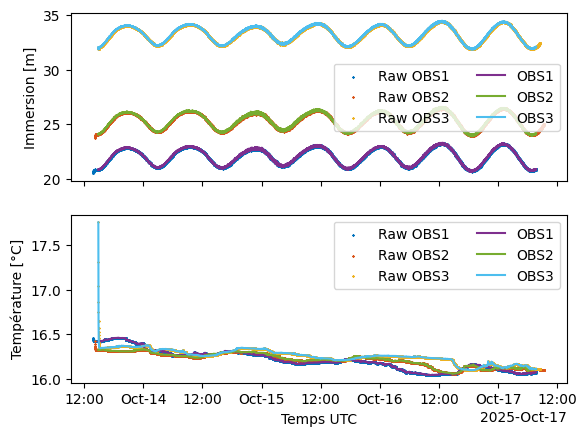

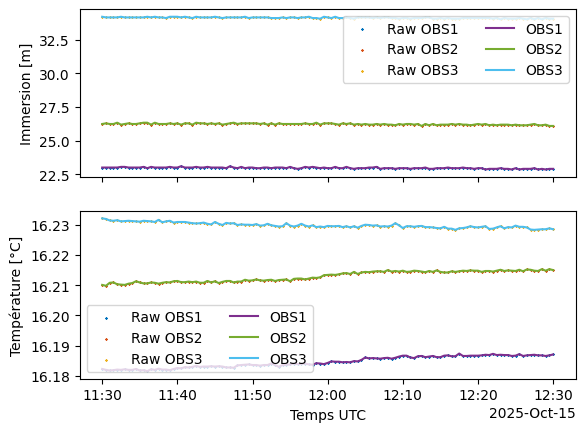

In [5]:
plot_SBE(ds_SBE=ds_SBE)

## Ondulation du géoide 

Afin de définir convenablement l'origine du repère local ENU utilisé ainsi que la hauteur ellipsoïdale associée à chacune des positions GPS (et donc la composante z de la position de la source dans le repère ENU), il est nécessaire de connaitre l'élévation du géoïde (qui coïncide avec le niveau moyen de la mer) au-dessus de l'ellipsoïde de référence. 

Quelques définitions / notations : 

* H : altitude orthométrique (altitude au-dessus du géoïde)
* h : altitude géographique (hauteur au-dessus de l'ellipsoïde de référence WGS84), c'est l'altitude donnée par le positionnement GPS standard. 
* N : ondulation du géoïde (hauteur du géoïde au-dessus de l'ellipsoïde de référence)

Ces trois grandeurs sont reliées par la relation suivante : 

$$
h \approx H + N 
$$

L'approximation est valide au niveau millimétrique. 

Afin d'accéder à l'ondulation du géoïde N dans la zone d'intérêt il est nécessaire d'utiliser un modèle global du champ de pesanteur terrestre. Le modèle couramment utilisé est le modèle EGM2008. L'EGM2008 (Earth Gravitational Model EGM2008) est un modèle global du champ de pesanteur
terrestre diffusé sous la forme d’harmoniques sphériques développés jusqu’à l’ordre 2159 (Pavlis et al., 2012). Il est issu de données de gravimétrie terrestres, aéroportées et spatiales.

En python, il semble que l'on puisse accéder à une estimation de l'ondulation du géoïde à l'aide de la librairie geoid_toolkit. Cependant, la fonction geoid_undulation(lat, lon, "WGS84", clm, slm, lmax, R, GM) nécessite de fournir les paramètres du développement en harmoniques sphériques. Par soucis de simplicité, et au vu des incertitudes sur le reste des coordonnées verticales que l'on manipule ici, on se contente ici d'une valeur fournie par le site web https://geographiclib.sourceforge.io/cgi-bin/GeoidEval?input=47.5+-3.5&option=Submit pour la position de référence (position a priori de l'OBS 2). 

$$
lon_0 = -3.464167^\circ, lat_0 = 47.669167^\circ
$$

$$
N(lon_0, lat_0) = 49.6795 ~\text{m (EGM2008)} 
$$

In [8]:
N_geoid_undulation = 49.6795

## Positions a priori des OBS

In [9]:
# Chargement des positions a priori
apriori_pos_wgs84_fname_before_campaign = (
    "pos_deg.csv"  # Theorical positions (as planned before the campaign)
)
apriori_pos_wgs84_before_campaign = pd.read_csv(
    os.path.join(root_groix_metadata, apriori_pos_wgs84_fname_before_campaign),
    index_col=0,
)
apriori_pos_wgs84_before_campaign["h"] = 0.0  # Dummmy initialisation as float

apriori_pos_wgs84_fname = (
    "pos_deg_relevee.csv"  # Position measured during the campaign 
)
apriori_pos_wgs84 = pd.read_csv(
    os.path.join(root_groix_metadata, apriori_pos_wgs84_fname),
    index_col=0,
)
apriori_pos_wgs84["h"] = 0.0    # Dummmy initialisation as float 

### Calcul des altitudes géographiques

Afin de calculer la hauteur géographique des positions a priori des OBS (et en particulier de l'OBS 2 que l'on considère comme origine du repère local dans la suite) on utilise la formule définie précédemment :
$$
h \approx H + N 
$$

L'altitude orthométrique H correspond à l'altitude au-dessus du géoïde, géoïde qui, dans l'océan, coïncide avec le niveau moyen de la mer. Ainsi, on peut estimer la composante H à partir des mesures de pression de chacun des capteurs. La pression traduit directement la hauteur de la colonne d'eau $z_{water}(t)$ au-dessus du capteur. La moyenne $<z_{water}(t)>$ de la hauteur de la colonne d'eau donne accès à H. 

$$
H = -<z_{water}(t)>
$$



In [10]:
z_mean_obs1 = ds_SBE.immersion_obs1.mean().values
z_mean_obs2 = ds_SBE.immersion_obs2.mean().values
z_mean_obs3 = ds_SBE.immersion_obs3.mean().values

print(f"z_obs1 = {z_mean_obs1} m, z_obs2 = {z_mean_obs2} m, z_obs3 = {z_mean_obs3} m")

z_obs1 = 22.032570916500234 m, z_obs2 = 25.295179737335832 m, z_obs3 = 33.21576651031895 m


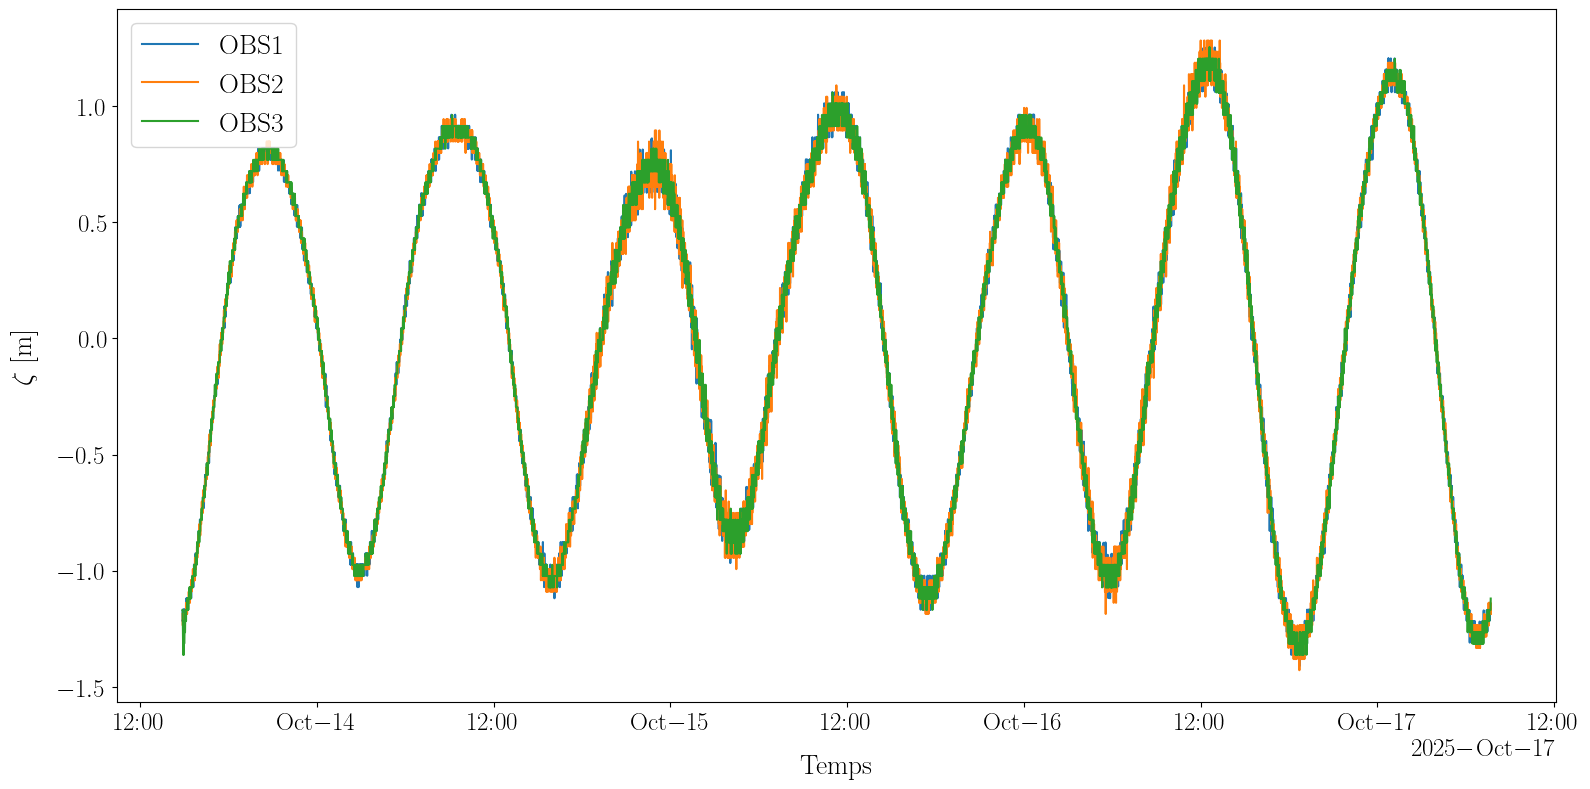

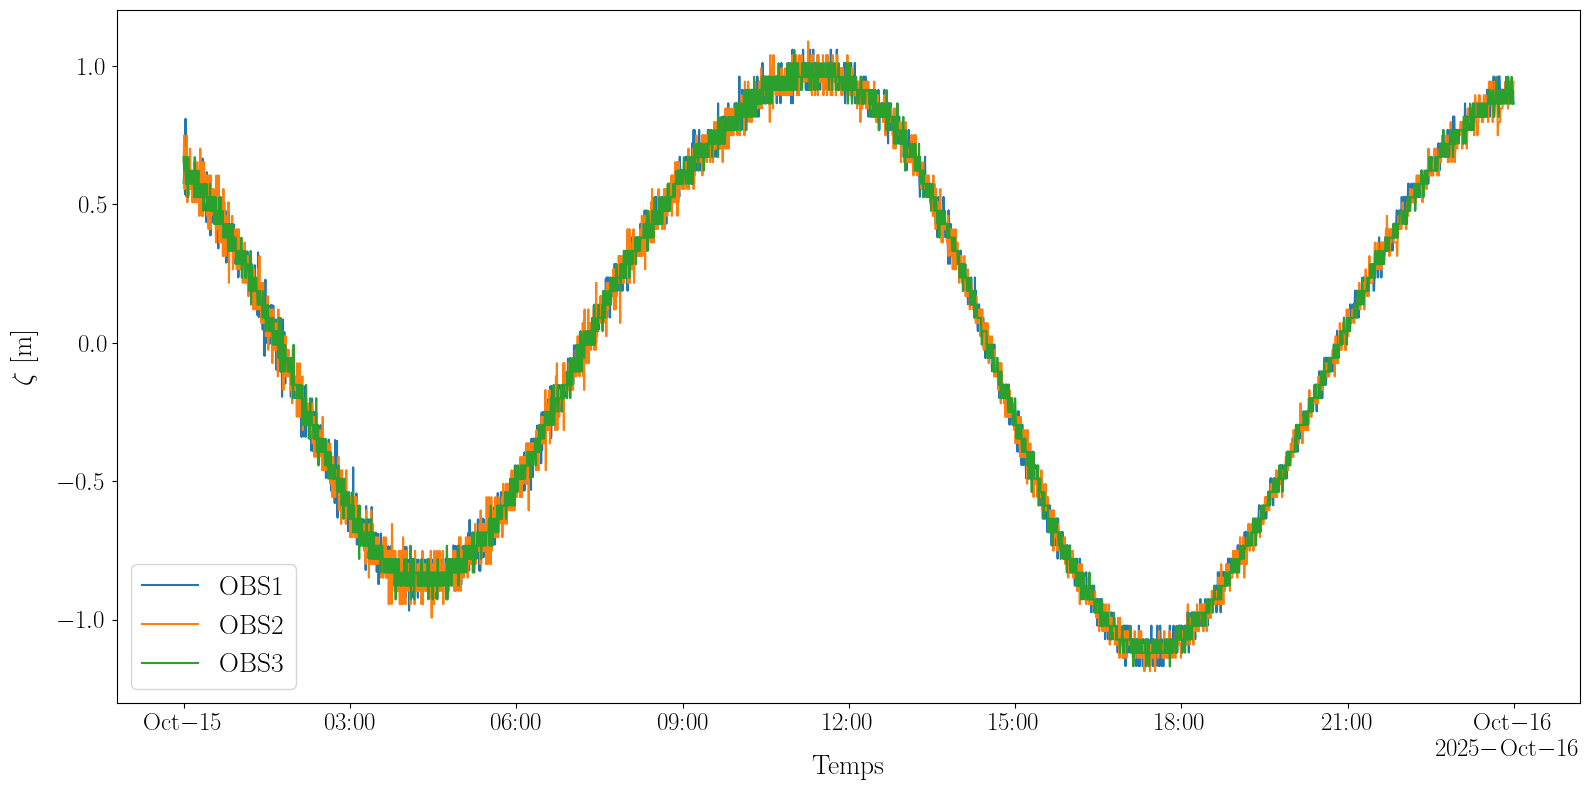

In [11]:
pfig = PubFigure(ticks_fontsize=18, label_fontsize=20)
plt.figure()
zeta_obs1 = ds_SBE.immersion_obs1 - z_mean_obs1
zeta_obs2 = ds_SBE.immersion_obs2 - z_mean_obs2
zeta_obs3 = ds_SBE.immersion_obs3 - z_mean_obs3

zeta_obs1.plot(label="OBS1")
zeta_obs2.plot(label="OBS2")
zeta_obs3.plot(label="OBS3")

plt.ylabel(r"$\zeta$ [m]")
plt.legend()

# Save figure
fpath = os.path.join(img_folder, "SBE39_zeta.png")
plt.savefig(fpath)

plt.figure()
day = "2025-10-15"
zeta_obs1 = ds_SBE.sel(time=day).immersion_obs1 - z_mean_obs1
zeta_obs2 = ds_SBE.sel(time=day).immersion_obs2 - z_mean_obs2
zeta_obs3 = ds_SBE.sel(time=day).immersion_obs3 - z_mean_obs3

zeta_obs1.plot(label="OBS1")
zeta_obs2.plot(label="OBS2")
zeta_obs3.plot(label="OBS3")
plt.ylabel(r"$\zeta$ [m]")
plt.legend()


In [12]:
# Cast to float 
apriori_pos_wgs84.loc["obs1", "h"] = N_geoid_undulation - z_mean_obs1
apriori_pos_wgs84.loc["obs2", "h"] = N_geoid_undulation - z_mean_obs2
apriori_pos_wgs84.loc["obs3", "h"] = N_geoid_undulation - z_mean_obs3
apriori_pos_wgs84.loc["t1", "h"] = N_geoid_undulation   # T1 position at sea level 
apriori_pos_wgs84.loc["t2", "h"] = N_geoid_undulation  # T1 position at sea level
apriori_pos_wgs84.loc["t3", "h"] = N_geoid_undulation  # T1 position at sea level
apriori_pos_wgs84.loc["t4", "h"] = N_geoid_undulation  # T1 position at sea level
apriori_pos_wgs84.loc["t5", "h"] = N_geoid_undulation  # T1 position at sea level


In [13]:
apriori_pos_wgs84

,lat,lon,h
id,,,
obs1,47.662280,-3.472260,27.646929
obs2,47.669110,-3.465840,24.384320
obs3,47.676760,-3.460270,16.463733
t1,47.661667,-3.467500,49.679500
t2,47.661667,-3.456667,49.679500
t3,47.661667,-3.445833,49.679500
t4,47.661667,-3.433333,49.679500
t5,47.661667,-3.420833,49.679500


In [14]:
# Coordonnées de le l'origine du repère de référence
obs_pos_id = "obs2"
pos0 = apriori_pos_wgs84.loc[obs_pos_id]
lat0 = np.radians(pos0.lat)
lon0 = np.radians(pos0.lon)
h0 = pos0.h

## Données bathy pour le fond de carte 

La zone sélectionnée est une zone de 0.25° x 0.25° soit environ 37.56 km x 55.6 km 

In [15]:
# Load bathy data
input_data_root = os.path.join(project_root, "data")
bathy_fpath = os.path.join(input_data_root, "bathy", "GEBCO_2021_sub_ice_topo.nc")
# bathy_fpath = r"/home/program/ubf_tools/data/bathy/mmdpm/PVA_RR48/GEBCO_2021_lon_64.44_67.44_lat_-29.08_-26.08.nc"

ds_bathy = xr.open_dataset(bathy_fpath)

# Slice data to get the area of interest
dlat_box = 0.25
dlon_box = 0.25
ds_bathy = ds_bathy.sel(
    lat=slice(
        pos0.lat - dlat_box,
        pos0.lat + dlat_box,
    ),
    lon=slice(
        pos0.lon - dlon_box,
        pos0.lon + dlon_box,
    ),
)

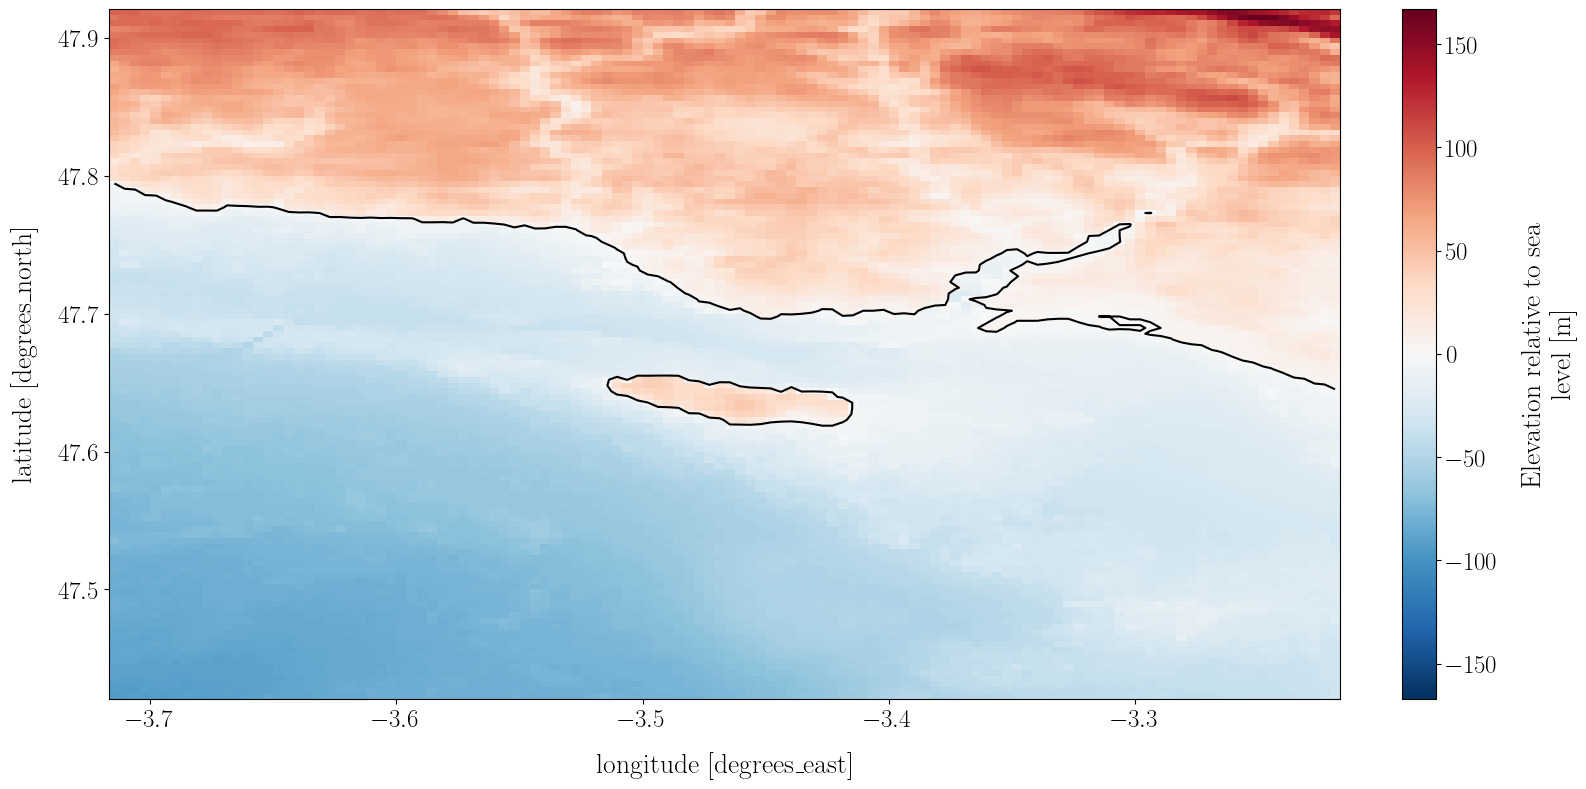

In [16]:
ds_bathy.elevation.plot()
# Add contours
plt.contour(
    ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
)

## Données AIS détramées par le SHOM et contenu dans le fichier SPATIONAV_AIS_001.csv



In [17]:
# Chargement des données AIS détramées par le SHOM 
columns = ["mmsi", "lon", "lat", "datetime"]
ais = pd.read_csv(ais_spationav_fpath, sep="\t", names=columns, header=None, usecols=[1, 2, 3, 4])

# Convert datetime column to datetime objects
ais["datetime"] = pd.to_datetime(ais["datetime"], format="%Y-%m-%d %H:%M:%S", utc=True)

# Remove AIS lines with unique positions (at least two points to define a trajectory)
ais = ais.groupby("mmsi").filter(lambda x: len(x) > 1)

# MMSI du Jules
mmsi_jules = 226916000
df_gps_jules = ais.loc[ais["mmsi"] == mmsi_jules]

## Données GPS au format (GPX)

### Chargement et extraction des données 

In [18]:
# Get all files within subfolders : folder = 13_10_25; files 13_10_25.txt
for root, dirs, files in os.walk(root_gps_not_parsed):
    for file in files:
        if file.endswith(".gpx"):
            fpath_in = os.path.join(root, file)
            fname = os.path.splitext(file)[0]
            root_output = os.path.join(root_groix_gps, os.path.basename(root))
            fpath_out = os.path.join(root_output, f"gps_pos_{fname}.csv")
            if not os.path.exists(root_output):
                os.makedirs(root_output)
            gpx_to_csv(gpx_file=fpath_in, csv_file=fpath_out)

✔ Conversion GPX → CSV terminée.
✔ 630 points GPS exportés dans c:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\gps\14_10_25\gps_pos_trace_14_10_25.csv.
✔ Conversion GPX → CSV terminée.
✔ 681 points GPS exportés dans c:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\gps\15_10_25\gps_pos_trace_15_10_25.csv.
✔ Conversion GPX → CSV terminée.
✔ 701 points GPS exportés dans c:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\gps\16_10_25\gps_pos_trace_16_10_25.csv.


### Mise en forme et concaténation 

In [19]:
gps_pos = {}
gps = pd.DataFrame()

for root, dirs, files in os.walk(root_groix_gps):
    for file in files:
        if file.endswith(".csv"):
            fpath_in = os.path.join(root, file)
            df_gps = pd.read_csv(fpath_in, sep=",")

            # Drop elevation column
            if "ele" in df_gps.columns:
                df_gps = df_gps.drop(columns=["ele"])

            # Convert time column to datetime
            df_gps["datetime"] = pd.to_datetime(df_gps["time"])

            # Drop original time column
            df_gps = df_gps.drop(columns=["time"])

            # Store in dictionary
            date = df_gps["datetime"].dt.date.unique()[0].strftime("%Y-%m-%d")
            # date = os.path.basename(root)
            # gps_pos[date] = df_gps
            gps = pd.concat([gps, df_gps], ignore_index=True)


## Interpolation des données GPS et des données AIS sur une base de temps régulière 

La période d'échantillonnage des données GPS et des données AIS n'est pas constante. Pour simplifier la suite du traitement on interpole la trajectoire du navire avec un pas de temps fixe de 10 secondes. La trajectoire est supposée rectiligne entre deux positions successives. 

In [20]:
time_step = "10s"  # 10 seconds

### Données GPS 

In [21]:
# Interpolate GPS data to regular time intervals
gps_interp = interpolate_gps(df_gps=gps, time_step=time_step)
gps_interp

,datetime,lon,lat
0,2025-10-14 08:29:30+00:00,-3.419913,47.659593
1,2025-10-14 08:29:40+00:00,-3.419893,47.659535
2,2025-10-14 08:29:50+00:00,-3.419845,47.659455
3,2025-10-14 08:30:00+00:00,-3.419642,47.659412
4,2025-10-14 08:30:10+00:00,-3.419508,47.659410
...,...,...,...
19635,2025-10-16 15:02:00+00:00,-3.476723,47.663689
19636,2025-10-16 15:02:10+00:00,-3.476043,47.663885
19637,2025-10-16 15:02:20+00:00,-3.475362,47.664081
19638,2025-10-16 15:02:30+00:00,-3.474682,47.664277


In [22]:
print()

### Données AIS 
Dans le cas des données AIS il faut interpoler chacune des trajectoires (i.e pour un MMSI donné) séparément.  

In [23]:
mmsi = ais.mmsi.unique()
# Ensure mmsi_jules is in mmsi in case we preprocess a subset of all the mmsis
mmsi = mmsi[0:10]
if mmsi_jules not in mmsi:
    mmsi= np.append(mmsi, mmsi_jules)

ais_interp = pd.DataFrame()

# Test progress bar
index0 = 0
indexf = mmsi.size - 1
prev_progress = 0

for i, mmsi_i in enumerate(mmsi):
    prev_progress = progression_bar(i, index0, indexf, prev_progress)

    ais_mmsi = ais.loc[ais["mmsi"] == mmsi_i]
    ais_mmsi_interp = interpolate_gps(df_gps=ais_mmsi, time_step=time_step)

    # Add mmsi column
    ais_mmsi_interp["mmsi"] = mmsi_i

    # if ais_mmsi_interp.empty:
    #     print("Empty dataframe for mmsi: ", mmsi_i)

    # Concatenate to ais_interp
    ais_interp = pd.concat([ais_interp, ais_mmsi_interp], ignore_index=True)

ais_interp

Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

,datetime,lon,lat,mmsi
0,2025-10-14 11:50:30+00:00,-3.552823,47.659437,228069260
1,2025-10-14 11:50:40+00:00,-3.552651,47.659327,228069260
2,2025-10-14 11:50:50+00:00,-3.552479,47.659216,228069260
3,2025-10-14 11:51:00+00:00,-3.552112,47.658996,228069260
4,2025-10-14 11:51:10+00:00,-3.551916,47.658888,228069260
...,...,...,...,...
112942,2025-10-17 09:46:50+00:00,-3.368668,47.704747,226916000
112943,2025-10-17 09:47:00+00:00,-3.368536,47.705036,226916000
112944,2025-10-17 09:47:10+00:00,-3.368278,47.705619,226916000
112945,2025-10-17 09:47:20+00:00,-3.368153,47.705914,226916000


## Conversion des coordonnées dans le repère ENU 

Dans la suite des manipulations on travaille en coordonnées locales ENU. Ce changement de repère permet en particulier de calculer des distances euclidiennes simplement. 

L'origine du repère local ENU est prise à la position a priori de l'OBS 2 situé au milieu de la fibre. 

In [24]:
# Coordonnées de l'origine du repère de référence local
obs_pos_id = "obs2"
pos0 = apriori_pos_wgs84.loc[obs_pos_id]
lat0 = np.radians(pos0.lat)
lon0 = np.radians(pos0.lon)
h0 = pos0.h    

### Calcul des coordonnées des OBS dans le repère local 

In [25]:
# WGS84 -> ECEF
lat = np.deg2rad(apriori_pos_wgs84.lat)
lon = np.deg2rad(apriori_pos_wgs84.lon)
X, Y, Z = geodetic_to_ecef(
    lat, lon, apriori_pos_wgs84.h
)
# ECEF -> ENU
e, n, u = ecef_to_enu(X, Y, Z, lat0, lon0, h0)

apriori_pos_enu = pd.DataFrame(np.stack((e, n, u)).T, index=apriori_pos_wgs84.index, columns=["e", "n", "u"])

In [26]:
apriori_pos_enu

,e,n,u
id,,,
obs1,-482.215316,-759.368786,3.199154
obs2,0.000000,0.000000,0.000000
obs3,418.254173,850.574497,-7.991060
t1,-124.686848,-827.583276,25.240207
t2,689.032537,-827.543835,25.204279
t3,1502.751897,-827.390652,25.064743
t4,2441.658783,-827.072568,24.774995
t5,3380.565552,-826.603054,24.347308


### Calcul des positions AIS dans le repère local

In [27]:
ais_lon = np.radians(ais_interp.lon)
ais_lat = np.radians(ais_interp.lat)
# Approximate height of the AIS antenna above sea level
ais_h_above_sea_level = 5       
# Sea level elevation above geoid = MSL
zeta_ais = zeta_obs1.sel(time=ais_interp["datetime"].values, method="nearest")
zeta_ais = 0
# AIS h above WGS84 ellipsoid
ais_h = N_geoid_undulation + zeta_ais + ais_h_above_sea_level
# WGS84 -> ECEF
x_ais, y_ais, z_ais = geodetic_to_ecef(ais_lat, ais_lon, ais_h)
# ECEF -> ENU
e_ais, n_ais, u_ais = ecef_to_enu(x_ais, y_ais, z_ais, lat0, lon0, h0)

### Calcul des positions GPS dans le repère local

In [28]:
gps_lon = np.radians(gps_interp.lon)
gps_lat = np.radians(gps_interp.lat)
gps_h = 5  # Approximate height of the AIS antenna above sea level      TODO : modifier avec la hauteur de l'ellipsoide plus la hauteur de l'antenne par rapport à la ligne de flottaison
# Approximate height of the GPS antenna above sea level     # TODO modifier avec les cotes du schéma du navire
gps_h_above_sea_level = 5
# Sea level elevation above geoid = MSL
zeta_gps = zeta_obs1.sel(time=gps_interp["datetime"].values, method="nearest")
zeta_gps = 0
# AIS h above WGS84 ellipsoid
gps_h = N_geoid_undulation + zeta_gps + gps_h_above_sea_level

# WGS84 -> ECEF
x_gps, y_gps, z_gps = geodetic_to_ecef(gps_lat, gps_lon, gps_h)
# ECEF -> ENU
e_gps, n_gps, u_gps = ecef_to_enu(x_gps, y_gps, z_gps, lat0, lon0, h0)

### Calcul des points de grille bathy dans le repère local 

In [29]:
bathy_lon = np.radians(ds_bathy.lon.values)
bathy_lat = np.radians(ds_bathy.lat.values)
bathy_h = 0  # Sea level
# WGS84 -> ECEF
x_bathy, y_bathy, z_bathy = geodetic_to_ecef(bathy_lat, bathy_lon, bathy_h)
# ECEF -> ENU
e_bathy, n_bathy, u_bathy = ecef_to_enu(x_bathy, y_bathy, z_bathy, lat0, lon0, h0)

## Sauvergarde des datasets importants dans le dossier local 

### Mise en forme des données AIS / GPS

In [30]:
# Reshape data and define common time vector
t_start = ais_interp["datetime"].min()
t_end = ais_interp["datetime"].max()
print(t_start, t_end)
common_time = pd.date_range(start=t_start, end=t_end, freq=time_step)

# ais_mat = []
ais_lon_mat = []
ais_lat_mat = []
# ais_enu_mat = []
ais_e_mat = []
ais_n_mat = []
ais_u_mat = []

for mmsi_i in mmsi:

    ais_mmsi = ais_interp.loc[ais_interp["mmsi"] == mmsi_i]
    ais_mmsi_arr = ais_mmsi.to_numpy(dtype=np.float32)[:, 1:3]  # Exclude time and mmsi column

    # Pad lon lat with NaNs to match common_time length
    n_pad_start = (ais_mmsi["datetime"].iloc[0] - t_start) // pd.Timedelta(time_step)
    n_pad_end = (t_end - ais_mmsi["datetime"].iloc[-1]) // pd.Timedelta(time_step)
    ais_mmsi_arr = np.pad(
        ais_mmsi_arr,
        ((n_pad_start, n_pad_end), (0, 0)),
        mode="constant",
        constant_values=np.nan,
    )
    # Pad e and n with NaNs to match common_time length
    e_ais_mmsi = e_ais[ais_mmsi.index]
    n_ais_mmsi = n_ais[ais_mmsi.index]
    u_ais_mmsi = u_ais[ais_mmsi.index]
    e_ais_mmsi = np.pad(
        e_ais_mmsi,
        (n_pad_start, n_pad_end),
        mode="constant",
        constant_values=np.nan,
    )
    n_ais_mmsi = np.pad(
        n_ais_mmsi,
        (n_pad_start, n_pad_end),
        mode="constant",
        constant_values=np.nan,
    )
    u_ais_mmsi = np.pad(
        u_ais_mmsi,
        (n_pad_start, n_pad_end),
        mode="constant",
        constant_values=np.nan,
    )

    # Add to array
    ais_lon_mat.append(ais_mmsi_arr[:, 0])
    ais_lat_mat.append(ais_mmsi_arr[:, 1])
    ais_e_mat.append(e_ais_mmsi)
    ais_n_mat.append(n_ais_mmsi)
    ais_u_mat.append(u_ais_mmsi)

    # ais_mat.append(ais_mmsi_arr)

# ais_mat = np.array(ais_mat)
ais_lon_mat = np.array(ais_lon_mat)
ais_lat_mat = np.array(ais_lat_mat)
ais_e_mat = np.array(ais_e_mat)
ais_n_mat = np.array(ais_n_mat)
ais_u_mat = np.array(ais_u_mat)


2025-10-13 08:00:50+00:00 2025-10-17 09:47:30+00:00


In [31]:
# Pad lon lat with NaNs to match common_time length
n_pad_start = (gps_interp["datetime"].iloc[0] - t_start) // pd.Timedelta(time_step)
n_pad_end = (t_end - gps_interp["datetime"].iloc[-1]) // pd.Timedelta(time_step)
gps_interp_lon = np.pad(
    gps_interp.lon,
    ((n_pad_start, n_pad_end)),
    mode="constant",
    constant_values=np.nan,
)
gps_interp_lat = np.pad(
    gps_interp.lat,
    ((n_pad_start, n_pad_end)),
    mode="constant",
    constant_values=np.nan,
)
# Also pad e and n with NaNs to match common_time length
e_gps = np.pad(
    e_gps,
    (n_pad_start, n_pad_end),
    mode="constant",
    constant_values=np.nan,
)
n_gps = np.pad(
    n_gps,
    (n_pad_start, n_pad_end),
    mode="constant",
    constant_values=np.nan,
)
u_gps = np.pad(
    u_gps,
    (n_pad_start, n_pad_end),
    mode="constant",
    constant_values=np.nan,
)

In [32]:
# On transforme tous les datataframes en xarray pour plus de simpliciter
ds_gps = xr.Dataset(
    data_vars=dict(
        raw_lon=(["raw_time"], gps.lon),
        raw_lat=(["raw_time"], gps.lat),
        lon=(["time"], gps_interp_lon),
        lat=(["time"], gps_interp_lat),
        e=(["time"], e_gps),
        n=(["time"], n_gps),
        u=(["time"], u_gps),
    ),
    coords=dict(
        time=common_time.tz_localize(None),
        raw_time=gps.datetime,
    ),
    attrs=dict(
        description="Positions GPS interpolées",
        interpolation_time_step=time_step,
        campagne="Fiberscope Groix Oct 2025",
        geodesic_frame="WGS84",
        local_frame="ENU",
        local_frame_origin=obs_pos_id,
        local_frame_origin_coordinates_wgs84_lon=pos0.lon,
        local_frame_origin_coordinates_wgs84_lat=pos0.lat,
        local_frame_origin_coordinates_wgs84_h=pos0.h,
    ),
)

# Add position of interest coords
for pos_id in apriori_pos_wgs84.index:
    for coord in ["lon", "lat", "h"]:
        ds_gps.attrs[f"{pos_id}_{coord}_apriori"] = apriori_pos_wgs84.loc[pos_id, coord]
for pos_id in apriori_pos_enu.index:
    for coord in ["e", "n", "u"]:
        ds_gps.attrs[f"{pos_id}_{coord}_apriori"] = apriori_pos_enu.loc[pos_id, coord]

# Add attributes to variables
ds_gps.raw_lon.attrs["units"] = "°"
ds_gps.raw_lat.attrs["units"] = "°"
ds_gps.lon.attrs["units"] = "°"
ds_gps.lat.attrs["units"] = "°"
ds_gps.e.attrs["units"] = "m"
ds_gps.n.attrs["units"] = "m"
ds_gps.u.attrs["units"] = "m"

ds_gps.raw_lon.attrs["long_name"] = "Longitude"
ds_gps.raw_lat.attrs["long_name"] = "Latitude"
ds_gps.lon.attrs["long_name"] = "Longitude"
ds_gps.lat.attrs["long_name"] = "Latitude"
ds_gps.e.attrs["long_name"] = "E"
ds_gps.n.attrs["long_name"] = "N"
ds_gps.u.attrs["long_name"] = "U"

ds_gps.time.attrs["timezone"] = "UTC"
ds_gps.raw_time.attrs["timezone"] = "UTC"

In [33]:
raw_ais_jules = ais.loc[ais["mmsi"] == mmsi_jules]
raw_ais_jules_arr = raw_ais_jules.to_numpy(dtype=np.float32)[
    :, 1:3
]  # Exclude time and mmsi column

ds_ais = xr.Dataset(
    data_vars=dict(
        raw_lon_jules=(["raw_time"], raw_ais_jules_arr[:, 0]),
        raw_lat_jules=(["raw_time"], raw_ais_jules_arr[:, 1]),
        lon=(["mmsi", "time"], ais_lon_mat),
        lat=(["mmsi", "time"], ais_lat_mat),
        e=(["mmsi", "time"], ais_e_mat),
        n=(["mmsi", "time"], ais_n_mat),
        u=(["mmsi", "time"], ais_u_mat),
    ),
    coords=dict(
        raw_time=raw_ais_jules.datetime,  # Remove timezone info for xarray compatibility
        time=common_time.tz_localize(None),     # Remove timezone info for xarray compatibility
        mmsi=ais_interp.mmsi.unique(),
    ),
    attrs=dict(
        description="Positions AIS interpolées",
        interpolation_time_step=time_step,
        campagne="Fiberscope Groix Oct 2025",
        geodesic_frame="WGS84",
        local_frame="ENU",
        local_frame_origin=obs_pos_id,
        local_frame_origin_coordinates_wgs84_lon=pos0.lon,
        local_frame_origin_coordinates_wgs84_lat=pos0.lat,
        local_frame_origin_coordinates_wgs84_h=pos0.h,
        mmsi_jules=mmsi_jules,
    ),
)

# Add position of interest coords 
for pos_id in apriori_pos_wgs84.index:
    for coord in ["lon", "lat", "h"]:
        ds_ais.attrs[f"{pos_id}_{coord}_apriori"] = apriori_pos_wgs84.loc[pos_id, coord]
for pos_id in apriori_pos_enu.index:
    for coord in ["e", "n", "u"]:
        ds_ais.attrs[f"{pos_id}_{coord}_apriori"] = apriori_pos_enu.loc[pos_id, coord]

# Add attributes to variables
ds_ais.raw_lon_jules.attrs["units"] = "°"
ds_ais.raw_lat_jules.attrs["units"] = "°"
ds_ais.lon.attrs["units"] = "°"
ds_ais.lat.attrs["units"] = "°"
ds_ais.e.attrs["units"] = "m"
ds_ais.n.attrs["units"] = "m"
ds_ais.u.attrs["units"] = "m"
ds_ais.mmsi.attrs["units"] = ""
ds_ais.time.attrs["timezone"] = "UTC"        
ds_ais.raw_time.attrs["timezone"] = "UTC"

ds_ais.raw_lon_jules.attrs["long_name"] = "Longitude"
ds_ais.raw_lat_jules.attrs["long_name"] = "Latitude"
ds_ais.lon.attrs["long_name"] = "Longitude"
ds_ais.lat.attrs["long_name"] = "Latitude"
ds_ais.e.attrs["long_name"] = "E"
ds_ais.n.attrs["long_name"] = "N"
ds_ais.u.attrs["long_name"] = "U"


In [34]:
ds_bathy = xr.Dataset(
    data_vars=dict(
        elevation=(["lat", "lon"], ds_bathy.elevation.values),
        elevation_enu=(["n", "e"], ds_bathy.elevation.values),
    ),
    coords=dict(
        lon=ds_bathy.lon.values,
        lat=ds_bathy.lat.values,
        e=e_bathy,
        n=n_bathy,
    ),
    attrs=dict(
        description="Bathymetry data from GEBCO 2021",
        geodesic_frame="WGS84",
        local_frame="ENU",
        local_frame_origin=obs_pos_id,
        local_frame_origin_coordinates_wgs84_lon=pos0.lon,
        local_frame_origin_coordinates_wgs84_lat=pos0.lat,
        local_frame_origin_coordinates_wgs84_h=pos0.h,
    ),
)

# Add attributes to variables
ds_bathy.elevation.attrs["units"] = "m"
ds_bathy.elevation_enu.attrs["units"] = "m"
ds_bathy.lon.attrs["units"] = "°"
ds_bathy.lat.attrs["units"] = "°"
ds_bathy.e.attrs["units"] = "m"
ds_bathy.n.attrs["units"] = "m"

ds_bathy.elevation.attrs["long_name"] = "Elevation (WGS84)"
ds_bathy.elevation_enu.attrs["long_name"] = "Elevation (ENU)"
ds_bathy.lon.attrs["long_name"] = "Longitude"
ds_bathy.lat.attrs["long_name"] = "Latitude"
ds_bathy.e.attrs["long_name"] = "E"
ds_bathy.n.attrs["long_name"] = "N"

In [35]:
# Save datasets to netcdf files
ds_gps.to_netcdf(os.path.join(data_folder, "gps.nc"))
ds_ais.to_netcdf(os.path.join(data_folder, "ais.nc"))
ds_bathy.to_netcdf(os.path.join(data_folder, "bathy.nc"))
ds_SBE.to_netcdf(os.path.join(data_folder, "sbe39_obs.nc"))